In [1]:
!pip install -q shap scikit-learn joblib pandas numpy

In [6]:
import sys
print(sys.executable)
!{sys.executable} -m pip install -q shap

/opt/micromamba/envs/jupyterlab/bin/python3


In [7]:
import shap
print(shap.__version__)

0.52.0


In [2]:
import pandas as pd
import numpy as np
import joblib
import json
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

df = pd.read_csv("data.csv")

GENDER_MAP = {"male": 0, "female": 1}
TARGET_MAP = {"no": 0, "yes": 1}

df["gender_enc"] = df["gender"].map(GENDER_MAP)
df["target_enc"] = df["target"].map(TARGET_MAP)

FEATURE_COLS = ["age", "gender_enc", "cp", "trestbps", "chol", "fbs",
                "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal"]
TARGET_COL = "target_enc"

df.head()

,sno,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,gender_enc,target_enc
0,0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes,0,1
1,1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes,0,1
2,2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes,1,1
3,3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes,0,1
4,4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes,1,1


In [3]:
IMPUTE_COLS = ["trestbps", "chol", "thalach"]
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df[TARGET_COL], random_state=42)

medians = {col: float(train_df[col].median()) for col in IMPUTE_COLS}
print("Training-set medians used for imputation:", medians)

for col in IMPUTE_COLS:
    train_df[col] = train_df[col].fillna(medians[col])
    test_df[col] = test_df[col].fillna(medians[col])

import os
os.makedirs("artifacts", exist_ok=True)
with open("artifacts/impute_medians.json", "w") as f:
    json.dump(medians, f)

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET_COL]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Training-set medians used for imputation: {'trestbps': 130.0, 'chol': 240.0, 'thalach': 152.0}
Train shape: (242, 13) Test shape: (61, 13)


In [4]:
model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

joblib.dump(model, "artifacts/model.joblib")
with open("artifacts/feature_cols.json", "w") as f:
    json.dump(FEATURE_COLS, f)

print("Model and artifacts saved.")

Accuracy: 0.819672131147541
Model and artifacts saved.


In [8]:
import shap

no_pred_mask = (y_pred == 0)
X_no_pred = X_test[no_pred_mask]
print(f"{no_pred_mask.sum()} samples predicted as 'no disease' out of {len(X_test)}")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_no_pred)

print("shap_values type/shape info:")
print(type(shap_values))
if hasattr(shap_values, "shape"):
    print(shap_values.shape)

21 samples predicted as 'no disease' out of 61
shap_values type/shape info:
<class 'numpy.ndarray'>
(21, 13, 2)


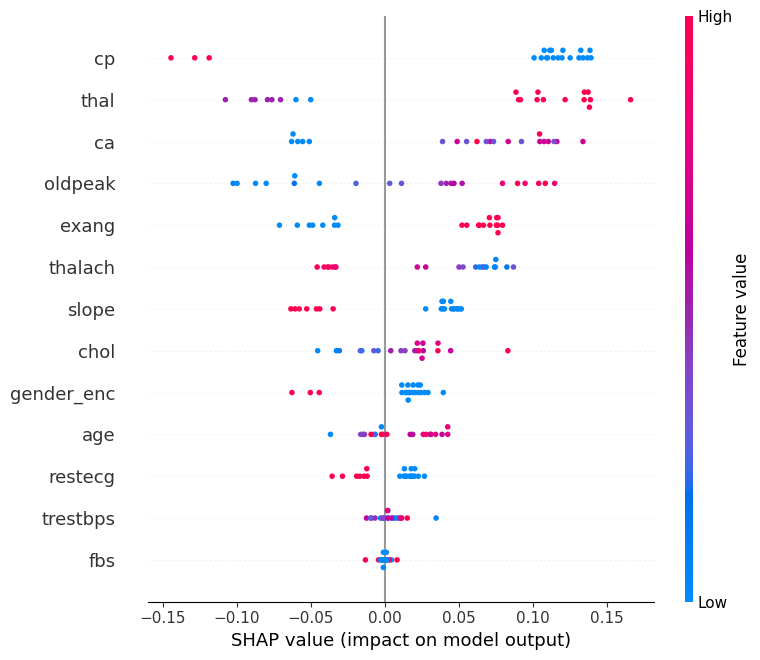

<Figure size 640x480 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt

# Handle both possible SHAP output shapes depending on version
if isinstance(shap_values, list):
    # Older SHAP: list of arrays, one per class
    values_for_no = shap_values[0]
elif hasattr(shap_values, "shape") and len(shap_values.shape) == 3:
    # Newer SHAP: single array (samples, features, classes)
    values_for_no = shap_values[:, :, 0]
else:
    values_for_no = shap_values

shap.summary_plot(
    values_for_no,
    X_no_pred,
    feature_names=FEATURE_COLS,
    show=True
)
plt.savefig("shap_no_prediction_summary.png", bbox_inches="tight")

In [ ]:
pwd 